<a href="https://colab.research.google.com/github/Victor-Tung/CS171_news_classification/blob/main/CS171_news_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Investigation


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Read the features file.
train_data = pd.read_csv('/content/drive/MyDrive/CS171/ag_train.csv',header=None,
                   names=['class', 'title', 'description'])
test_data = pd.read_csv('/content/drive/MyDrive/CS171/ag_test.csv',header=None,
                   names=['class', 'title', 'description'])
#first 30 lines are all class index 3, data set is well balanced
print(train_data['class'].value_counts().sort_index())
print('-----------------------------------')
train_data.tail(5)


class
1              30000
2              30000
3              30000
4              30000
Class Index        1
Name: count, dtype: int64
-----------------------------------


,class,title,description
119996,1,Pakistan's Musharraf Says Won't Quit as Army Chief,"KARACHI (Reuters) - Pakistani President Pervez Musharraf has said he will stay on as army chief, reneging on a pledge to quit the powerful post by the end of the year."
119997,2,Renteria signing a top-shelf deal,"Red Sox general manager Theo Epstein acknowledged Edgar Renteria was more a luxury for the 2005 Red Sox than a necessity. But there's nothing wrong with getting the keys to a BMW, and that's what the four-time All-Star and two-time Gold Glover is in the eyes of the Red Sox."
119998,2,Saban not going to Dolphins yet,"The Miami Dolphins will put their courtship of LSU coach Nick Saban on hold to comply with the NFL's hiring policy by interviewing at least one minority candidate, a team source told The Associated Press last night."
119999,2,Today's NFL games,"PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: Steelers by 10. Records: Steelers 12-1, Giants 5-8. Vs. spread: Steelers 10-1-2, Giants 5-8. Series: Giants lead, 43-27-3. Comments: Think the Giants knew Ben Roethlisberger was available on draft day when they broke the bank and traded for Eli Manning? . . . All Big Ben has done this year is complete ..."
120000,2,Nets get Carter from Raptors,"INDIANAPOLIS -- All-Star Vince Carter was traded by the Toronto Raptors to the New Jersey Nets for Alonzo Mourning, Eric Williams, Aaron Williams, and a pair of first-round draft picks yesterday."


In [ ]:
train_data.shape

(120001, 3)

In [ ]:
train_data.columns

Index(['class', 'title', 'description'], dtype='object')

In [ ]:
train_data.dtypes

,0
class,object
title,object
description,object


# Data Preprocessing and Cleaning


In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)        # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # collapse extra whitespace
    text = ' '.join([w for w in text.split() if w not in stop_words])  # remove stopwords
    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
train_data['title_clean'] = train_data['title'].apply(clean_text)
train_data['description_clean'] = train_data['description'].apply(clean_text)
train_data['text'] = train_data['title_clean'] + ' ' + train_data['description_clean']

In [ ]:
test_data['title_clean'] = test_data['title'].apply(clean_text)
test_data['description_clean'] = test_data['description'].apply(clean_text)
test_data['text'] = test_data['title_clean'] + ' ' + test_data['description_clean']

In [ ]:
# testing clean function
test_val = 5000
print("BEFORE:", train_data['title'].iloc[test_val])
print("AFTER: ", train_data['title_clean'].iloc[test_val])
print()
print("BEFORE:", train_data['description'].iloc[test_val])
print("AFTER: ", train_data['description_clean'].iloc[test_val])
train_data.head(5)

BEFORE: General Growth Properties to acquire Rouse for \$12.6 bn
AFTER:  general growth properties acquire rouse 12 6 bn

BEFORE: NEW YORK, August 20 (New Ratings)  General Growth Properties Inc (GGP.NYS), the second-largest shopping mall operator in the US, has agreed to buy Rouse Company (RSE), in a cash and debt assumptions deal worth about \$12.6 billion. 
AFTER:  new york august 20 new ratings general growth properties inc ggp nys second largest shopping mall operator us agreed buy rouse company rse cash debt assumptions deal worth 12 6 billion


,class,title,description,title_clean,description_clean,text
0,Class Index,Title,Description,title,description,title description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",wall st bears claw back black reuters,reuters short sellers wall street dwindling band ultra cynics seeing green,wall st bears claw back black reuters reuters short sellers wall street dwindling band ultra cynics seeing green
2,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.",carlyle looks toward commercial aerospace reuters,reuters private investment firm carlyle group reputation making well timed occasionally controversial plays defense industry quietly placed bets another part market,carlyle looks toward commercial aerospace reuters reuters private investment firm carlyle group reputation making well timed occasionally controversial plays defense industry quietly placed bets another part market
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.,oil economy cloud stocks outlook reuters,reuters soaring crude prices plus worries economy outlook earnings expected hang stock market next week depth summer doldrums,oil economy cloud stocks outlook reuters reuters soaring crude prices plus worries economy outlook earnings expected hang stock market next week depth summer doldrums
4,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),"Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.",iraq halts oil exports main southern pipeline reuters,reuters authorities halted oil export flows main pipeline southern iraq intelligence showed rebel militia could strike infrastructure oil official said saturday,iraq halts oil exports main southern pipeline reuters reuters authorities halted oil export flows main pipeline southern iraq intelligence showed rebel militia could strike infrastructure oil official said saturday


# Building/Training Custom CNN


In [ ]:
train_data = train_data[train_data["class"] != "Class Index"].copy()
test_data = test_data[test_data["class"] != "Class Index"].copy()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Raw data
train_texts = train_data["text"].astype(str).values
train_labels = train_data["class"].values

test_texts = test_data["text"].astype(str).values
test_labels = test_data["class"].values


# Downsample ONLY the training set to 50,000, preserving class balance
train_texts, _, train_labels, _ = train_test_split(
    train_texts,
    train_labels,
    train_size=10000,
    random_state=42,
    stratify=train_labels
)

# Fit label encoder on training labels, then transform both
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(train_labels)
y_test_int = label_encoder.transform(test_labels)

# One-hot encode for Keras
y_train = to_categorical(y_train_int)
y_test = to_categorical(y_test_int)

# Fit tokenizer on training texts only
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# Transform both train and test texts
X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)

# Pad sequences the same way for both
X_train = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.6416 - loss: 0.9226 - val_accuracy: 0.8755 - val_loss: 0.3882
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9154 - loss: 0.2879 - val_accuracy: 0.8865 - val_loss: 0.3365
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9693 - loss: 0.1135 - val_accuracy: 0.8705 - val_loss: 0.4185
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9919 - loss: 0.0355 - val_accuracy: 0.8795 - val_loss: 0.4997
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9976 - loss: 0.0135 - val_accuracy: 0.8810 - val_loss: 0.5667
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.9977 - loss: 0.0096 - val_accuracy: 0.8725 - val_loss: 0.6380
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9996 - loss: 0.0048 - val_accuracy: 0.8770 - val_loss: 0.7012
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9992 - loss: 0.0047 - 

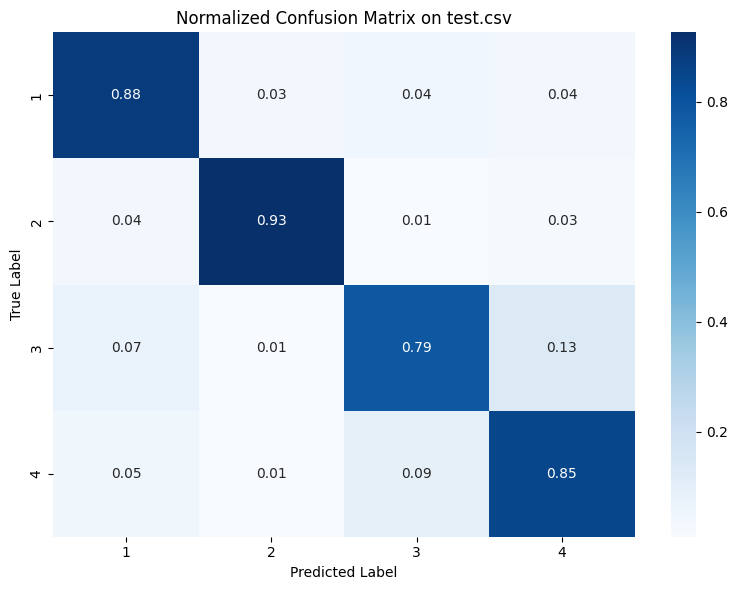

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

embedding_dim = 128
num_classes = y_train.shape[1]

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=X_train.shape[1]),
    Conv1D(filters=128, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train only on train.csv
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

# Test only on test.csv
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions on test.csv
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

predicted_labels = label_encoder.inverse_transform(y_pred)
true_labels = label_encoder.inverse_transform(y_true)

print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels, digits=4))

cm = confusion_matrix(true_labels, predicted_labels, labels=label_encoder.classes_)
print("\nConfusion Matrix:\n")
print(cm)

cm_normalized = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix on test.csv")
plt.tight_layout()
plt.show()

# Fine-tuning DistilBERT

# Compare/Constrast Results